## Logistic Regression

In this notebook, we'll walk step-by-step through performing logistic regression using the Titanic dataset. We'll cover each of the following steps clearly and thoroughly:

1. Loading and inspecting the dataset.
2. Preprocessing: Handling missing values and encoding categorical data.
3. Splitting the data into training and testing sets.
4. Training a logistic regression model.
5. Evaluating the model's performance.
6. Checking assumptions for logistic regression.
7. Interpreting the model's results clearly.

### **Step 1: Load and Inspect the Data**
We'll use the Titanic dataset, a popular dataset for predicting passenger survival based on various features.

In [12]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Load Titanic dataset in seaborn
df = sns.load_dataset('titanic')

# Inspect the dataset
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## **Step 2: Preprocess the Data**
Before training our model, we must prepare the dataset. This step involves two key processes:

*2.1 Handle Missing Values*
Logistic regression requires datasets without missing values, so we remove rows with missing data in important columns (age, embarked).

*2.2 Encode Categorical Variables*
Machine learning algorithms require numerical inputs. Therefore, categorical variables (sex, embarked) must be converted into numeric form using one-hot encoding.

- Why encoding?
    - Converts categorical labels into numeric values that the model can interpret.
    - Avoids misinterpretation of categorical variables as numeric variables (e.g., treating "male" as numerically greater or less than "female").

In [13]:
# Handling missing values
df.dropna(subset=['age'], inplace=True)

# Encoding categorical variables
# Use drop_first = True to avoid "dummy trap"
df = pd.get_dummies(df, columns=['sex'], drop_first=True) # Use drop_first = True to avoid "dummy trap"

# Define features and target
features = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']
X = df[features]
y = df['survived']

# Preview the cleaned dataset
print(X.head())
print(y.head())

   pclass   age  sibsp  parch     fare  sex_male
0       3  22.0      1      0   7.2500      True
1       1  38.0      1      0  71.2833     False
2       3  26.0      0      0   7.9250     False
3       1  35.0      1      0  53.1000     False
4       3  35.0      0      0   8.0500      True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


## **Step 3: Split the Data**
We divide our dataset into two subsets:
- *Training Set*: To build our logistic regression model.
- *Testing Set*: To evaluate the performance of our model.

In [14]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

## **Step 4: Train the Logistic Regression Model**
We'll now build and train our logistic regression model using the training data.

In [17]:
from sklearn.linear_model import LogisticRegression

# Initialize and train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)


c:\Users\tommy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## **Step 5: Evaluate the Model**
To understand how well our model predicts survival, we use the following evaluation metrics:
- *Accuracy*: Proportion of correct predictions.
- *Confusion Matrix*: Breakdown of predictions (True positives, True negatives, False positives, False negatives).
- *Classification Report*: Precision, recall, and F1-score.

0.7482517482517482


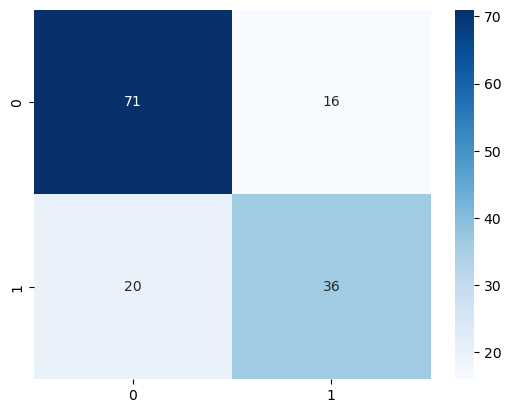

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        87
           1       0.69      0.64      0.67        56

    accuracy                           0.75       143
   macro avg       0.74      0.73      0.73       143
weighted avg       0.75      0.75      0.75       143



In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict on test data
y_pred = model.predict(X_test)


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt = "d", cmap="Blues")
plt.show()
# Display classification report
print(classification_report(y_test, y_pred))

## **Step 6: Examining and Interpreting the Model**
After training our logistic regression model, let's examine the coefficients to understand their meaning in more detail.
- Coefficients in logistic regression represent the effect of each feature on the log-odds of the target (survival in this case).
- Positive coefficients increase the odds of the outcome (survival).
- Negative coefficients decrease the odds of the outcome (survival).
- The magnitude of coefficients shows the strength of each feature's influence.

### 6.1 Interpreting Coefficients
After training our logistic regression model, let's examine the coefficients to understand their meaning in more detail.
- Coefficients in logistic regression represent the effect of each feature on the log-odds of the target (survival in this case).
- Positive coefficients increase the odds of the outcome (survival).
- Negative coefficients decrease the odds of the outcome (survival).
- The magnitude of coefficients shows the strength of each feature's influence.

Output:
- Coefficient Interpretation:
    - Positive coefficients: Increase the log-odds (and thus probability) of survival.
    - Negative coefficients: Decrease the log-odds (and thus probability) of survival.



| Feature      | Coefficient | Impact on Survival Probability                      | Explanation                                                    |
|--------------|-------------|-----------------------------------------------------|----------------------------------------------------------------|
| `pclass`     | -1.21       | Decreases                                           | Lower passenger classes (higher numeric values) decrease survival odds.            |
| `age`        | -0.04       | Slight negative impact                              | Older passengers have slightly lower odds of survival.         |
| `sibsp`      | -0.35       | Negative impact                                     | Having more siblings/spouses aboard decreases survival odds.   |
| `parch`      | -0.05       | Slight negative impact                              | Having more parents/children aboard slightly reduces odds.     |
| `fare`       | 0.002      | Very slight positive impact                         | Paying higher fares slightly increases survival odds.          |
| `sex_male`   | -2.61       | Strong negative impact                              | Being male greatly decreases the probability of survival.      |
| **Intercept**| 5.47        | Baseline log-odds                                   | Baseline survival odds for females with lowest-class, fare, and minimal age. |


In [21]:
# Extract coefficients and intercept
coef = pd.Series(model.coef_[0], index=features)
intercept = model.intercept_[0]

# Display coefficients
print("Model Coefficients:")
print(coef)

print("\nIntercept:", intercept)

Model Coefficients:
pclass     -1.212806
age        -0.048921
sibsp      -0.354642
parch      -0.058082
fare        0.002091
sex_male   -2.614334
dtype: float64

Intercept: 5.468442851599297


### 6.2 Understanding the `predict_proba` Function
Logistic regression outputs probabilities between 0 and 1, indicating the likelihood of belonging to a specific class.
- The function predict_proba() returns two columns:
    - Probability of class 0 (not survived).
    - Probability of class 1 (survived).
- Output:
    - Each row gives the probability of not surviving (first column) and surviving (second column).
    - Useful for making informed decisions based on probabilities rather than just binary predictions.

In [23]:
# Get predicted probabilities for the test set
probabilities = model.predict_proba(X_test)

# Display probabilities for first 5 test observations
print("Predicted Probabilities for first 5 passengers (Not_Survival=0 and Survival=1):")
print(probabilities[:5])
print(y_pred[:5])


Predicted Probabilities for first 5 passengers (Not_Survival=0 and Survival=1):
[[0.83187924 0.16812076]
 [0.5229319  0.4770681 ]
 [0.21018084 0.78981916]
 [0.03818395 0.96181605]
 [0.94656756 0.05343244]]
[0 0 1 1 0]


In [25]:
X_test[:5]

,pclass,age,sibsp,parch,fare,sex_male
149,2,42.0,0,0,13.00,True
407,2,3.0,1,1,18.75,True
53,2,29.0,1,0,26.00,False
369,1,24.0,0,0,69.30,False
818,3,43.0,0,0,6.45,True
